# Module 8: Scaling — Practice Problems

এই notebook-এ real datasets ব্যবহার করে scaling-এর সব concepts practice করা হবে।

**Datasets used:**
- California Housing Dataset
- Diabetes Dataset
- Breast Cancer Dataset
- Wine Dataset

সব dataset sklearn থেকে directly load করা যাবে — কোনো external file লাগবে না।

---
## Setup — Run this first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_diabetes, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

print('Setup complete!')

Setup complete!


---
# Part 1: Why Scaling Matters
**Dataset: California Housing**

### Problem 1
California Housing dataset load করো এবং একটি DataFrame বানাও।
প্রতিটি feature-এর min, max এবং mean print করো।
দেখো feature-গুলোর range কতটা আলাদা।

In [2]:
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Your code here: print min, max, mean of each feature

df_housing.describe()

# AveRoom er max 141.9 -> is a outlier
# population er std onek beshi -> scaling kra lagbe
# AveBedrms, AveOccup er max ta outlier
# AveOccup is right skewed, as mean is 3.07 and median is 2.82, same for population
#


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


### Problem 2
California Housing dataset-এর সব features-এর distribution একসাথে plot করো (histogram)।
কোন features-এর range সবচেয়ে বড়? কোনটা সবচেয়ে ছোট? চিহ্নিত করো।

array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

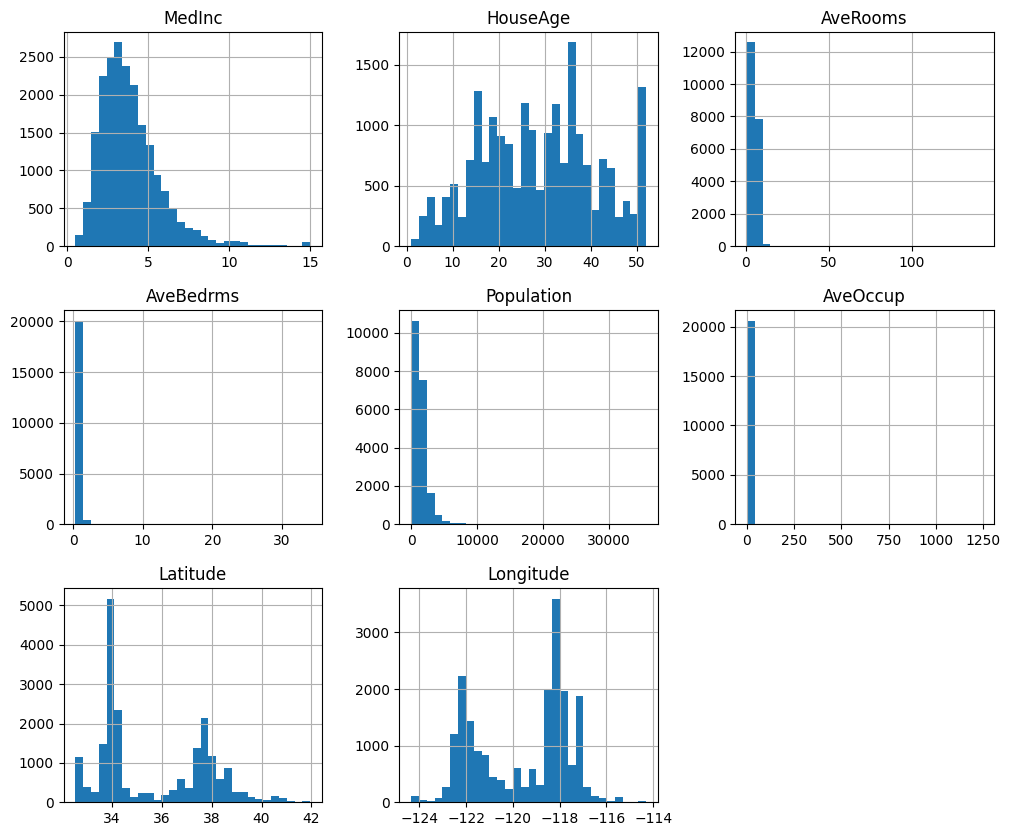

In [3]:
# Your code here: plot histogram for all features
df_housing.hist(
    figsize=(12, 10),
    bins=30
)


In [4]:
feature_ranges = pd.DataFrame({
    'Min': df_housing.min(),
    'Max': df_housing.max(),
})

feature_ranges['Range'] = (
    feature_ranges['Max']
    - feature_ranges['Min']
)

print(feature_ranges.sort_values(
    by='Range',
    ascending=False
))



                   Min           Max         Range
Population    3.000000  35682.000000  35679.000000
AveOccup      0.692308   1243.333333   1242.641026
AveRooms      0.846154    141.909091    141.062937
HouseAge      1.000000     52.000000     51.000000
AveBedrms     0.333333     34.066667     33.733333
MedInc        0.499900     15.000100     14.500200
Longitude  -124.350000   -114.310000     10.040000
Latitude     32.540000     41.950000      9.410000


### Problem 3
Diabetes dataset load করো। Features-এর scale দেখে বলো —
scaling ছাড়া কোন ধরনের ML model সবচেয়ে বেশি সমস্যায় পড়বে এবং কেন?
(KNN, Decision Tree — এই তিনটির মধ্যে তুলনা করো।)

In [5]:
# Load diabetes dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Your code here: explore and answer
df_diabetes.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


KNN distance-based algorithm।

এটা Euclidean distance ব্যবহার করে

Decision Tree distance ব্যবহার করে না।

এটা এমন split করে:

bmi < 0.02 ?
bp > 0.01 ?

তাই feature scale বড় বা ছোট হলে Decision Tree প্রায় একই থাকে।

---
# Part 2: Standard Scaling
**Dataset: Breast Cancer**

### Problem 4
Breast Cancer dataset load করো এবং train-test split করো (test_size=0.2, random_state=42)।
এরপর StandardScaler দিয়ে শুধু training data-তে fit করো এবং দুটোতেই transform করো।

In [6]:
# Load dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

# Your code here: train-test split, fit StandardScaler on train, transform both
X = df_cancer
y=y_cancer
X_train, X_test,y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



### Problem 5
Problem 4-এর scaled training data-র mean এবং standard deviation print করো।
Expected output: mean ≈ 0, std ≈ 1।
যদি এই output না পাও, কোথায় ভুল হয়েছে খুঁজে বের করো।

In [7]:
# Your code here: verify mean and std after scaling
print(X_train_scaled.mean())
print(X_train_scaled.std())

-9.442670495742283e-16
1.0


### Problem 6
Breast Cancer dataset-এর যেকোনো একটি feature নিয়ে scaling-এর আগে এবং পরে
KDE plot পাশাপাশি (subplot) দেখাও।
Shape কি একই থাকে নাকি বদলে যায়?

In [8]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

<Axes: xlabel='mean texture', ylabel='Density'>

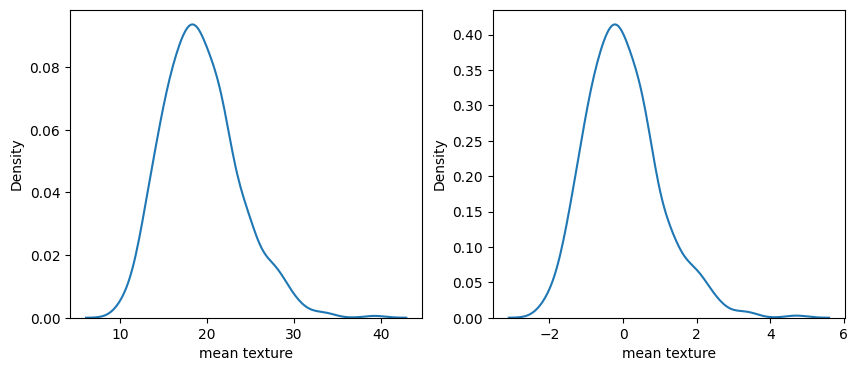

In [9]:
# Your code here: before vs after KDE plot side by side
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_cancer['mean texture'])

plt.subplot(1, 2, 2)
sns.kdeplot(data=X_train_scaled_df['mean texture'])

Shape same in here

### Problem 7
StandardScaler manually implement করো — sklearn ব্যবহার না করে।
formula: z = (x - mean) / std
Diabetes dataset-এর 'bmi' column-এ apply করো এবং sklearn-এর output-এর সাথে মিলিয়ে দেখো।

In [10]:
# Your code here: manual StandardScaler and compare with sklearn
mean = df_diabetes['bmi'].mean()
std = df_diabetes['bmi'].std()
df_diabetes_copy = df_diabetes.copy()
df_diabetes_copy['bmi_scaled'] = (df_diabetes['bmi'] - mean) / std

scaler = StandardScaler()
scaler.fit(df_diabetes[['bmi']])
scaler.transform(df_diabetes[['bmi']])
print(df_diabetes[['bmi']])
print(df_diabetes_copy['bmi_scaled'])



          bmi
0    0.061696
1   -0.051474
2    0.044451
3   -0.011595
4   -0.036385
..        ...
437  0.019662
438 -0.015906
439 -0.015906
440  0.039062
441 -0.073030

[442 rows x 1 columns]
0      1.295620
1     -1.080955
2      0.933475
3     -0.243495
4     -0.764079
         ...   
437    0.412892
438   -0.334032
439   -0.334032
440    0.820305
441   -1.533636
Name: bmi_scaled, Length: 442, dtype: float64


---
# Part 3: MinMax Scaling
**Dataset: Wine**

### Problem 8
Wine dataset load করো। MinMaxScaler apply করো সব features-এ।
Scaled data-র min এবং max verify করো — সব feature-এ min=0 এবং max=1 হওয়া উচিত।

In [11]:
# Load dataset
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Your code here: apply MinMaxScaler and verify min/max
scaler = MinMaxScaler()
scaler.fit(df_wine)
df_wine_scaled = scaler.transform(df_wine)
df_wine_scaled_df = pd.DataFrame(df_wine_scaled, columns=df_wine.columns)
df_wine_scaled_df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.518584,0.315484,0.538244,0.458502,0.323278,0.453487,0.356386,0.437460,0.372523,0.322363,0.388170,0.491460,0.334446
std,0.213639,0.220780,0.146708,0.172142,0.155244,0.215811,0.210730,0.234818,0.180555,0.197806,0.185831,0.260070,0.224613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350658,0.170455,0.454545,0.340206,0.195652,0.262931,0.182489,0.264151,0.264984,0.165529,0.245935,0.244505,0.158702
50%,0.531579,0.222332,0.534759,0.458763,0.304348,0.474138,0.378692,0.396226,0.361199,0.290956,0.394309,0.553114,0.282097
75%,0.696711,0.462945,0.640374,0.561856,0.402174,0.627586,0.534810,0.580189,0.485804,0.419795,0.520325,0.695971,0.504280
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Problem 9
MinMaxScaler manually implement করো — sklearn ব্যবহার না করে।
formula: x_scaled = (x - min) / (max - min)
Wine dataset-এর 'alcohol' column-এ apply করো এবং sklearn output-এর সাথে তুলনা করো।

In [12]:
# Your code here: manual MinMaxScaler and compare with sklearn
min = df_wine['alcohol'].min()
max = df_wine['alcohol'].max()

df_wine_copy = df_wine.copy()
df_wine_copy['alcohol_scaled'] = (df_wine['alcohol'] - min) / (max - min)

scaler= MinMaxScaler()
scaler.fit(df_wine[['alcohol']])
df_wine_copy['alcohol_scaled_sklearn']=scaler.transform(df_wine[['alcohol']]).ravel()
print(df_wine_copy[['alcohol_scaled_sklearn']])
print(df_wine_copy['alcohol_scaled'])


     alcohol_scaled_sklearn
0                  0.842105
1                  0.571053
2                  0.560526
3                  0.878947
4                  0.581579
..                      ...
173                0.705263
174                0.623684
175                0.589474
176                0.563158
177                0.815789

[178 rows x 1 columns]
0      0.842105
1      0.571053
2      0.560526
3      0.878947
4      0.581579
         ...   
173    0.705263
174    0.623684
175    0.589474
176    0.563158
177    0.815789
Name: alcohol_scaled, Length: 178, dtype: float64


### Problem 10
Wine dataset-এ একটি artificial outlier যোগ করো (যেমন: alcohol = 500)।
MinMaxScaler apply করার পর দেখো বাকি সব values কীভাবে প্রভাবিত হয়।
Before এবং after plot করো।

<Axes: xlabel='alcohol_scaled', ylabel='Density'>

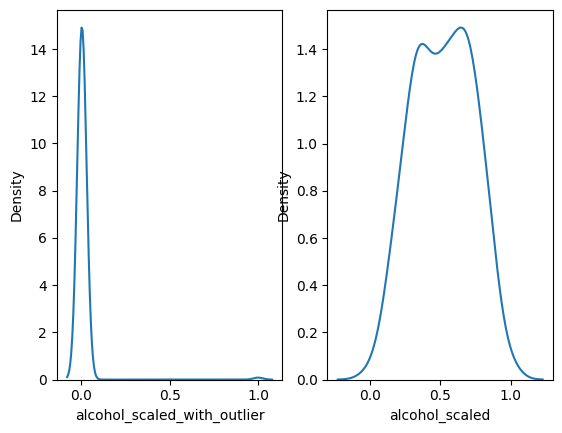

In [13]:
# Your code here: add outlier, apply MinMaxScaler, plot before vs after

df_wine_outlier = df_wine.copy()
df_wine_outlier.loc[0, 'alcohol'] = 500 # Row 0-কে outlier বানানো

scaler = MinMaxScaler()
scaler.fit(df_wine_outlier[['alcohol']])
df_wine_outlier['alcohol_scaled_with_outlier'] = scaler.transform(df_wine_outlier[['alcohol']])



plt.subplot(1,2,1)
sns.kdeplot(data=df_wine_outlier['alcohol_scaled_with_outlier'])
plt.subplot(1,2,2)
sns.kdeplot(df_wine_copy['alcohol_scaled'])

### Problem 11
একই outlier-যুক্ত Wine data-তে এবার StandardScaler apply করো।
MinMaxScaler vs StandardScaler — কোনটা outlier-এ বেশি ক্ষতিগ্রস্ত হয়েছে?
দুটির output plot করে তুলনা করো।

<Axes: xlabel='alcohol_scaled_with_outlier', ylabel='Density'>

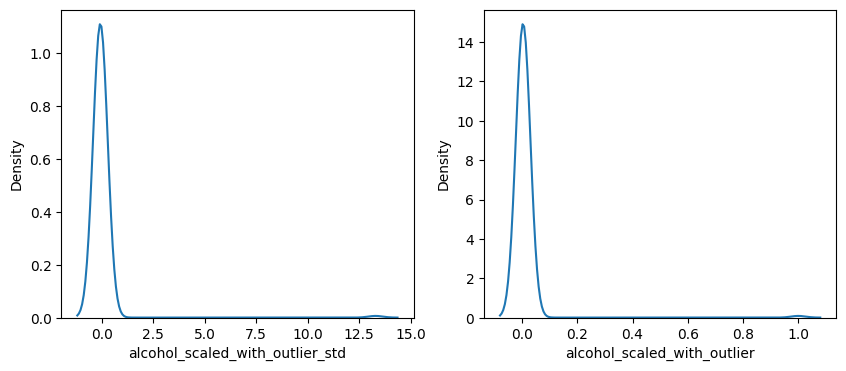

In [14]:
# Your code here: compare MinMaxScaler vs StandardScaler with outlier present
scaler = StandardScaler()
scaler.fit(df_wine_outlier[['alcohol']])
df_wine_outlier['alcohol_scaled_with_outlier_std'] = scaler.transform(df_wine_outlier[['alcohol']])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.kdeplot(data=df_wine_outlier['alcohol_scaled_with_outlier_std'])
plt.subplot(1,2,2)
sns.kdeplot(data=df_wine_outlier['alcohol_scaled_with_outlier'])

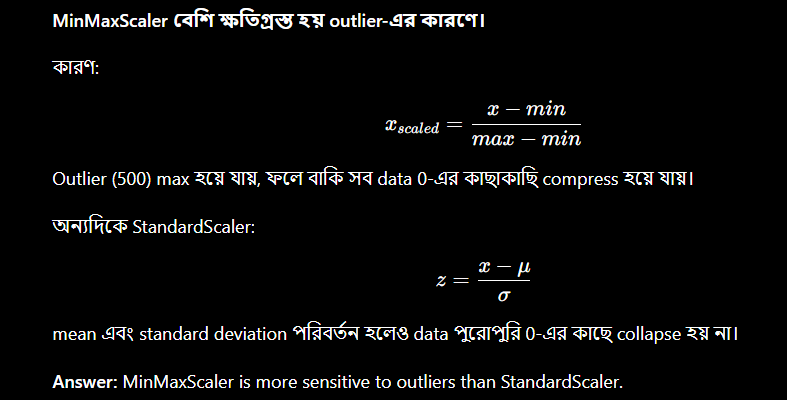

---
# Part 4: Robust Scaler
**Dataset: California Housing**

### Problem 12
California Housing dataset-এ 'AveRooms' column-এ RobustScaler apply করো।
Scaled data-র median এবং IQR print করো।
Expected: median ≈ 0।

In [15]:
# Your code here: RobustScaler on AveRooms, check median and IQR
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

scaler = RobustScaler()
df_housing['AveRooms_scaled'] = scaler.fit_transform(df_housing[['AveRooms']])

print(df_housing['AveRooms_scaled'].median())
print(df_housing['AveRooms_scaled'].quantile(0.75) - df_housing['AveRooms_scaled'].quantile(0.25))

0.0
1.0000000000000002


### Problem 13
RobustScaler manually implement করো।
formula: x_scaled = (x - median) / IQR
California Housing-এর 'AveOccup' column-এ apply করো এবং sklearn output-এর সাথে মিলিয়ে দেখো।

In [16]:
# Your code here: manual RobustScaler and compare with sklearn
median = df_housing['AveOccup'].median()
iqr = df_housing['AveOccup'].quantile(0.75) - df_housing['AveOccup'].quantile(0.25)
df_housing['AveOccup_scaled'] = (df_housing['AveOccup'] - median) / iqr

print(df_housing['AveOccup_scaled'])


scaler = RobustScaler()
df_housing['AveOccup_scaled_skleaen'] = scaler.fit_transform(df_housing[['AveOccup']])

print(df_housing['AveOccup_scaled_skleaen'])

0       -0.307981
1       -0.830800
2       -0.018599
3       -0.316908
4       -0.746784
           ...   
20635   -0.302057
20636    0.357401
20637   -0.577676
20638   -0.815121
20639   -0.235929
Name: AveOccup_scaled, Length: 20640, dtype: float64
0       -0.307981
1       -0.830800
2       -0.018599
3       -0.316908
4       -0.746784
           ...   
20635   -0.302057
20636    0.357401
20637   -0.577676
20638   -0.815121
20639   -0.235929
Name: AveOccup_scaled_skleaen, Length: 20640, dtype: float64


### Problem 14
California Housing-এর 'AveRooms' column-এ তিনটি scaler একসাথে compare করো:
StandardScaler, MinMaxScaler, RobustScaler।
তিনটির output এর KDE plot পাশাপাশি (3 subplots) দেখাও।
কোনটা outlier-এ সবচেয়ে কম প্রভাবিত হয়েছে?

<Axes: xlabel='AveOccup_scaled_skleaen', ylabel='Density'>

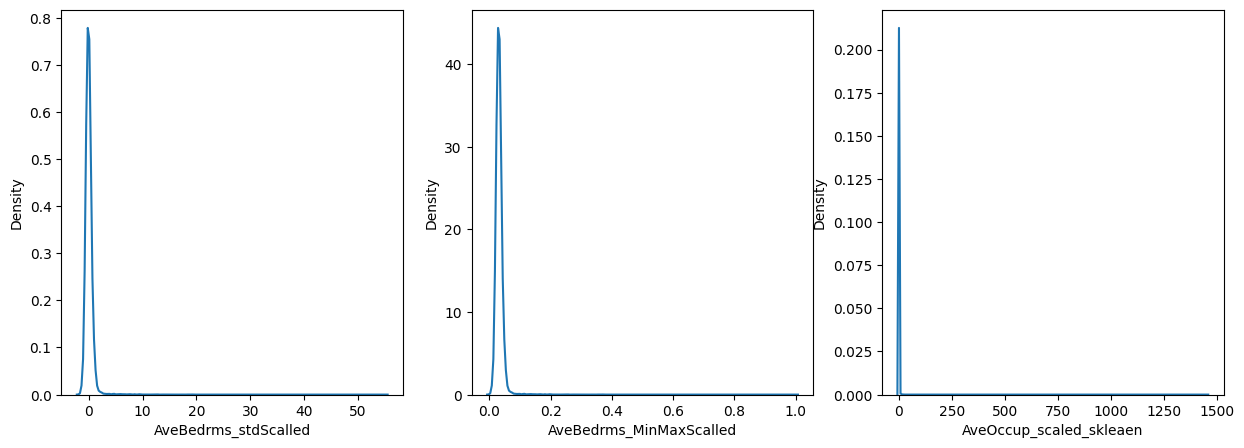

In [17]:
# Your code here: compare all 3 scalers side by side with KDE plots
scaler = StandardScaler()
df_housing['AveBedrms_stdScalled']=scaler.fit_transform(df_housing[['AveRooms']]).ravel()

scaler = MinMaxScaler()
df_housing['AveBedrms_MinMaxScalled']=scaler.fit_transform(df_housing[['AveRooms']]).ravel()

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.kdeplot(data=df_housing['AveBedrms_stdScalled'])
plt.subplot(1,3,2)
sns.kdeplot(data=df_housing['AveBedrms_MinMaxScalled'])
plt.subplot(1,3,3)
sns.kdeplot(data=df_housing['AveOccup_scaled_skleaen'])


Outlier-এর কারণে সবচেয়ে কম প্রভাবিত হয় RobustScaler।

কারণ RobustScaler median এবং IQR ব্যবহার করে:

### Problem 15
Data leakage experiment করো:
- Case A: Scaler শুধু train data-তে fit করো, test-এ transform করো।
- Case B: Scaler পুরো dataset-এ fit করো, তারপর split করো।

Diabetes dataset ব্যবহার করো। দুই case-এ test set-এর mean এবং std print করো।
পার্থক্য দেখাও এবং কোনটা সঠিক তা explain করো।

In [18]:
# Your code here: demonstrate data leakage vs correct approach
# Load diabetes dataset
diabetes = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)


X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split( X,
    y,
    test_size=0.2,
    random_state=42)
# ==========================
# CASE A (Correct)
# Fit only on TRAIN
# ==========================
scaler_A = StandardScaler()

X_train_A = scaler_A.fit_transform(X_train)
X_test_A = scaler_A.transform(X_test)


# ==========================
# CASE B (Wrong)
# Fit on WHOLE DATASET
# ==========================
scaler_B = StandardScaler()

# Leakage happens here
scaler_B.fit(X)

X_train_B = scaler_B.transform(X_train)
X_test_B = scaler_B.transform(X_test)


print("CASE A (No Leakage)")
print("Test Mean:")
print(np.round(X_test_A.mean(axis=0), 4))

print("\nTest Std:")
print(np.round(X_test_A.std(axis=0), 4))


print("\n\nCASE B (Data Leakage)")
print("Test Mean:")
print(np.round(X_test_B.mean(axis=0), 4))

print("\nTest Std:")
print(np.round(X_test_B.std(axis=0), 4))

CASE A (No Leakage)
Test Mean:
[-0.1548 -0.0192 -0.1826 -0.121   0.0578  0.0842  0.1046 -0.0392 -0.1264
 -0.1944]

Test Std:
[1.1239 0.9987 1.0241 0.9047 0.9826 0.9973 1.0566 0.9829 0.973  0.9042]


CASE B (Data Leakage)
Test Mean:
[-0.1202 -0.0153 -0.1447 -0.0983  0.0463  0.0672  0.0825 -0.0314 -0.1014
 -0.1577]

Test Std:
[1.0933 0.9989 1.0164 0.9206 0.9858 0.9973 1.0435 0.9862 0.977  0.9184]


---
# Part 5: ColumnTransformer
**Dataset: California Housing**

### Problem 16
California Housing dataset-এ নিচের transformation apply করো ColumnTransformer দিয়ে:
- 'MedInc', 'AveRooms' → StandardScaler
- 'Latitude', 'Longitude' → MinMaxScaler
- বাকি সব columns → passthrough (কোনো change নেই)

Train-test split করে শুধু train-এ fit করো।

In [19]:
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [20]:
# Your code here: ColumnTransformer with mixed scaling



X = df_housing
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['MedInc', 'AveRooms']),
        ('minmax', MinMaxScaler(), ['Latitude', 'Longitude'])], remainder='passthrough'
)

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print("Train Shape:", X_train_transformed.shape)
print("Test Shape :", X_test_transformed.shape)


Train Shape: (16512, 8)
Test Shape : (4128, 8)


### Problem 17
Problem 16-এর ColumnTransformer-এ RobustScaler যোগ করো:
- 'AveOccup', 'AveBedrms' → RobustScaler

এখন তিনটি scaler একই pipeline-এ আছে।
Output DataFrame-এর shape এবং প্রথম 5 rows print করো।

In [30]:
# Your code here: ColumnTransformer with all 3 scalers
# Your code here: ColumnTransformer with mixed scaling



X = df_housing
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['MedInc', 'AveRooms']),
        ('minmax', MinMaxScaler(), ['Latitude', 'Longitude']),
        ('robust',RobustScaler(),['AveOccup', 'AveBedrms'])], remainder='passthrough'
)

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print("Train Shape:", X_train_transformed.shape)
print("Test Shape :", X_test_transformed.shape)
X_train.head(5)

Train Shape: (16512, 8)
Test Shape : (4128, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


### Problem 18
ColumnTransformer-এর `remainder='drop'` এবং `remainder='passthrough'` এর পার্থক্য কী?
California Housing dataset-এ দুটি case try করো এবং output shape তুলনা করো।

In [31]:
# Your code here: compare remainder='drop' vs remainder='passthrough'
# Load dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
X = df_housing
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)


# case 01
preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['MedInc', 'AveRooms']),
        ('minmax', MinMaxScaler(), ['Latitude', 'Longitude']),
        ('robust',RobustScaler(),['AveOccup', 'AveBedrms'])
                                                                ],
      remainder='drop'
)

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print("Train Shape:", X_train_transformed.shape)
print("Test Shape :", X_test_transformed.shape)
X_train.head(5)


Train Shape: (16512, 6)
Test Shape : (4128, 6)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80


### Problem 19
Wine dataset-এ সব numeric features-এ StandardScaler apply করো ColumnTransformer দিয়ে।
এরপর `set_output(transform='pandas')` ব্যবহার করে output-কে DataFrame হিসেবে রাখো।
Column names ঠিক আছে কিনা verify করো।

In [36]:
# Your code here: ColumnTransformer with set_output pandas
df_wine_c = df_wine.copy()
df_wine_numeric = df_wine.select_dtypes(include=np.number).columns

preprocessor = ColumnTransformer(transformers=[('std', StandardScaler(), df_wine_numeric)], remainder ='passthrough')
preprocessor.set_output(transform='pandas')
preprocessor.fit(df_wine_c)
df_scaled = preprocessor.transform(df_wine_c)
print(type(df_scaled))
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   std__alcohol                       178 non-null    float64
 1   std__malic_acid                    178 non-null    float64
 2   std__ash                           178 non-null    float64
 3   std__alcalinity_of_ash             178 non-null    float64
 4   std__magnesium                     178 non-null    float64
 5   std__total_phenols                 178 non-null    float64
 6   std__flavanoids                    178 non-null    float64
 7   std__nonflavanoid_phenols          178 non-null    float64
 8   std__proanthocyanins               178 non-null    float64
 9   std__color_intensity               178 non-null    float64
 10  std__hue                           178 non-null    float64
 11  std__od280/od315_of_

---
# Part 6: End-to-End Challenge Problems
এই problems-গুলো সব concepts একসাথে ব্যবহার করে।

### Problem 20 ⭐
Breast Cancer dataset নিয়ে পুরো preprocessing pipeline তৈরি করো:
1. Train-test split (80-20)
2. তিনটি scaler আলাদা আলাদাভাবে apply করো
3. প্রতিটি scaler-এর পর mean এবং std print করো
4. কোন scaler-এর output সবচেয়ে stable সেটা বলো

শুধু train-এ fit করতে ভুলো না।

In [38]:
# Breast Cancer Dataset
# Full preprocessing pipeline with 3 scalers

import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# =====================================================
# Load Dataset
# =====================================================

cancer = load_breast_cancer()

df_cancer = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

X = df_cancer
y = cancer.target


# =====================================================
# Train-Test Split (80-20)
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # changed here ↓ (80-20 split)
    random_state=42
)


# =====================================================
# StandardScaler
# =====================================================

standard_scaler = StandardScaler()

# fit only on train
standard_scaler.fit(X_train)

# changed here ↓
# save transformed train data
X_train_std = standard_scaler.transform(X_train)

# transform test data
X_test_std = standard_scaler.transform(X_test)

print("========== StandardScaler ==========")
print("Mean:", X_train_std.mean())
print("Std :", X_train_std.std())
print()


# =====================================================
# MinMaxScaler
# =====================================================

minmax_scaler = MinMaxScaler()

# fit only on train
minmax_scaler.fit(X_train)

# changed here ↓
X_train_minmax = minmax_scaler.transform(X_train)

X_test_minmax = minmax_scaler.transform(X_test)

print("========== MinMaxScaler ==========")
print("Mean:", X_train_minmax.mean())
print("Std :", X_train_minmax.std())
print()


# =====================================================
# RobustScaler
# =====================================================

robust_scaler = RobustScaler()

# fit only on train
robust_scaler.fit(X_train)

# changed here ↓
X_train_robust = robust_scaler.transform(X_train)

X_test_robust = robust_scaler.transform(X_test)

print("========== RobustScaler ==========")
print("Mean:", X_train_robust.mean())
print("Std :", X_train_robust.std())
print()


# =====================================================
# Shapes
# =====================================================

print("Original Train Shape :", X_train.shape)
print("Standard Shape      :", X_train_std.shape)
print("MinMax Shape        :", X_train_minmax.shape)
print("Robust Shape        :", X_train_robust.shape)


# =====================================================
# Conclusion
# =====================================================

print("\nConclusion:")

print(
    "StandardScaler usually gives the most stable output "
    "when data does not contain many extreme outliers."
)

print(
    "RobustScaler is more stable when significant outliers exist "
    "because it uses median and IQR."
)

print(
    "MinMaxScaler is most sensitive to outliers because it depends "
    "on minimum and maximum values."
)

========== StandardScaler ==========
Mean: -9.442670495742283e-16
Std : 1.0

========== MinMaxScaler ==========
Mean: 0.23974350103388578
Std : 0.1754478000986615

========== RobustScaler ==========
Mean: 0.21110958695697554
Std : 0.967743598144815

Original Train Shape : (455, 30)
Standard Shape      : (455, 30)
MinMax Shape        : (455, 30)
Robust Shape        : (455, 30)

Conclusion:
StandardScaler usually gives the most stable output when data does not contain many extreme outliers.
RobustScaler is more stable when significant outliers exist because it uses median and IQR.
MinMaxScaler is most sensitive to outliers because it depends on minimum and maximum values.


### Problem 21 ⭐
California Housing dataset-এ outlier detection করো:
1. 'AveOccup' column-এর boxplot দেখাও
2. IQR method দিয়ে outlier চিহ্নিত করো
3. Outlier সরানোর আগে এবং পরে StandardScaler apply করো
4. দুই ক্ষেত্রে scaled data-র describe() তুলনা করো

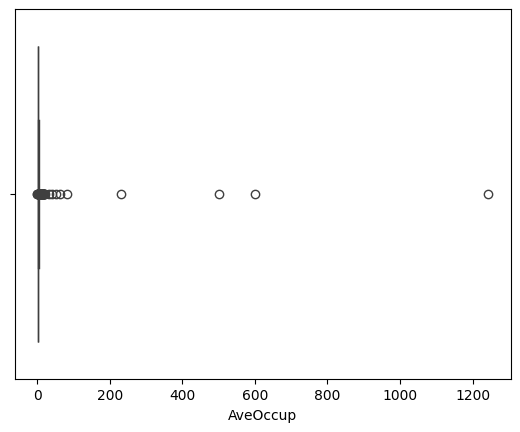

Number of Outliers: 711

Before Removing Outliers
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  2.064000e+04  2.064000e+04  2.064000e+04  2.064000e+04  2.064000e+04   
mean   6.609700e-17  5.508083e-18  6.609700e-17 -1.060306e-16 -1.101617e-17   
std    1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00   
min   -1.774299e+00 -2.196180e+00 -1.852319e+00 -1.610768e+00 -1.256123e+00   
25%   -6.881186e-01 -8.453931e-01 -3.994496e-01 -1.911716e-01 -5.638089e-01   
50%   -1.767951e-01  2.864572e-02 -8.078489e-02 -1.010650e-01 -2.291318e-01   
75%    4.593063e-01  6.643103e-01  2.519615e-01  6.015869e-03  2.644949e-01   
max    5.858286e+00  1.856182e+00  5.516324e+01  6.957171e+01  3.025033e+01   

           AveOccup      Latitude     Longitude  
count  2.064000e+04  2.064000e+04  2.064000e+04  
mean   3.442552e-18 -1.079584e-15 -8.526513e-15  
std    1.000024e+00  1.000024e+00  1.000024e+00  
min   -2.290000e-01 -1.447568e+00 -2.3

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing()

df_housing = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# =========================================
# Boxplot
# =========================================

sns.boxplot(x=df_housing['AveOccup'])
plt.show()

# =========================================
# IQR Outlier Detection
# =========================================

Q1 = df_housing['AveOccup'].quantile(0.25)
Q3 = df_housing['AveOccup'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_housing[
    (df_housing['AveOccup'] < lower_bound) |
    (df_housing['AveOccup'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

# =========================================
# Scaling BEFORE removing outliers
# =========================================

scaler = StandardScaler()

df_scaled_before = pd.DataFrame(
    scaler.fit_transform(df_housing),
    columns=df_housing.columns
)

print("\nBefore Removing Outliers")
print(df_scaled_before.describe())

# =========================================
# Remove Outliers
# =========================================

df_nooutlier = df_housing[
    (df_housing['AveOccup'] >= lower_bound) &
    (df_housing['AveOccup'] <= upper_bound)
]

# =========================================
# Scaling AFTER removing outliers
# =========================================

df_scaled_after = pd.DataFrame(
    scaler.fit_transform(df_nooutlier),
    columns=df_nooutlier.columns
)

print("\nAfter Removing Outliers")
print(df_scaled_after.describe())

### Problem 22 ⭐
নিচের scenario-তে কোন scaler ব্যবহার করবে এবং কেন — code দিয়ে prove করো:

- Scenario A: Diabetes dataset-এর 'bmi' — normally distributed, কোনো extreme outlier নেই
- Scenario B: California Housing-এর 'AveOccup' — heavily skewed, extreme outliers আছে
- Scenario C: Wine dataset-এর 'alcohol' — neural network-এ input দেওয়া হবে

প্রতিটিতে correct scaler apply করো এবং output plot করো।

<Axes: ylabel='Density'>

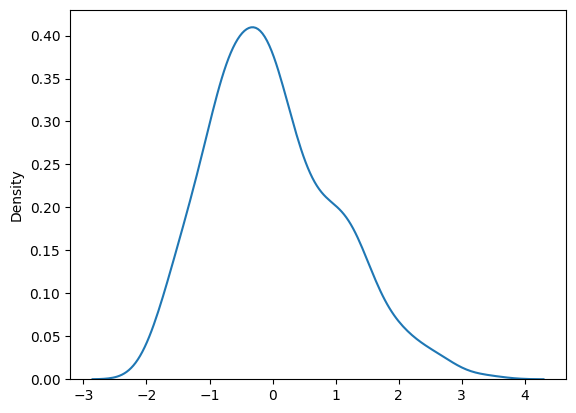

In [45]:
# Your code here: choose correct scaler for each scenario
# for scenario A:
# Normaly distributed -> standard scaler

scaler = StandardScaler()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaled = scaler.fit_transform(X_train[['bmi']]).ravel()
sns.kdeplot(scaled)
 # same vabe bakigula


### Problem 23 ⭐
California Housing dataset-এ একটি complete ColumnTransformer pipeline তৈরি করো:
- 'MedInc' → StandardScaler (normally distributed income)
- 'Latitude', 'Longitude' → MinMaxScaler (geographic coordinates for neural net)
- 'AveOccup', 'AveRooms' → RobustScaler (skewed with outliers)
- বাকি columns → passthrough

Train-test split করে properly fit ও transform করো।
Final X_train এবং X_test shape print করো।

In [47]:
# Your code here: complete ColumnTransformer pipeline
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
X = df_housing
y = housing.target
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['MedInc']),
        ('minmax', MinMaxScaler(), ['Latitude', 'Longitude']),
        ('robust',RobustScaler(),['AveOccup', 'AveRooms'])
                                                                ],
      remainder='passthrough'
)

preprocessor.fit(X_train)
X_train_transformed =preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)

print(X_test_transformed.shape)

(16512, 8)
(4128, 8)


### Problem 24 ⭐
Scaler-এর inverse_transform কী কাজ করে?
Wine dataset-এ StandardScaler apply করো।
এরপর inverse_transform দিয়ে original values ফিরিয়ে আনো।
Original এবং recovered values কি same? Verify করো।

In [48]:
# Your code here: apply StandardScaler and then inverse_transform
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# =====================================================
# Load Dataset
# =====================================================

wine = load_wine(as_frame=True)

df = wine.frame

# changed here ↓
# remove target column
X = df.drop('target', axis=1)

print("Original Data:")
print(X.head())


# =====================================================
# Apply StandardScaler
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data:")
print(X_scaled[:5])


# =====================================================
# Recover Original Data
# =====================================================

# changed here ↓
X_recovered = scaler.inverse_transform(X_scaled)

# changed here ↓
X_recovered = pd.DataFrame(
    X_recovered,
    columns=X.columns
)

print("\nRecovered Data:")
print(X_recovered.head())

Original Data:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0   

In [49]:
difference = X - X_recovered

print(difference.abs().max())

alcohol                         0.000000e+00
malic_acid                      8.881784e-16
ash                             0.000000e+00
alcalinity_of_ash               0.000000e+00
magnesium                       0.000000e+00
total_phenols                   2.220446e-16
flavanoids                      1.110223e-16
nonflavanoid_phenols            0.000000e+00
proanthocyanins                 2.775558e-16
color_intensity                 1.776357e-15
hue                             0.000000e+00
od280/od315_of_diluted_wines    2.220446e-16
proline                         5.684342e-14
dtype: float64


### Problem 25 ⭐
Final challenge: Data leakage এর real impact দেখাও।

Diabetes dataset-এ:
- Case A (Correct): train-এ fit, test-এ transform
- Case B (Wrong): full data-তে fit, তারপর split

দুই case-এ test set-এর scaled values-এর mean ও std compare করো।
পার্থক্য কতটুকু? Real-world-এ এই পার্থক্য কেন সমস্যা তৈরি করে সেটা comment-এ লেখো।

In [29]:
# Your code here: demonstrate real impact of data leakage
